# Notebook 1.5 — Constraint Binding Attribution

This notebook is a direct extension of the `2026-01-26` SA1 case study in `Price_Spike_Autopsy.ipynb`.

It stays tightly scoped to one event window and answers one practical question: which constraints carried non-zero marginal value, when did they bind, and how did that line up with SA-VIC price separation and elevated `V-SA` flow?

**Required `import_nem_data.py` command:**
```bash
uv run import_nem_data.py --start 2025/01/01 --end 2026/02/28 --dispatchconstraint --dispatchprice --dispatchregionsum
```

**Also required:**
- `DISPATCHINTERCONNECTORRES` for `2025/01/01` to `2026/02/28`. `import_nem_data.py` does **not** currently expose a flag for this table, so populate it separately with:
```bash
uv run python - <<'PY'
from nemosis import cache_compiler
cache_compiler(
    "2025/01/01 00:00:00",
    "2026/02/28 23:55:00",
    "DISPATCHINTERCONNECTORRES",
    "./data/nemosis_cache",
    fformat="parquet",
)
PY
```

Scope note:
- This is interval-level binding attribution, not full NEMDE equation decomposition.
- It does not use `GENCONDATA`.
- Constraint-identification context comes from event-period `DISPATCHCONSTRAINT` fields: `CONSTRAINTID`, `GENCONID_EFFECTIVEDATE`, and `GENCONID_VERSIONNO`.


In [2]:
import re
from datetime import datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
from dateutil.relativedelta import relativedelta
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 120

PROJECT_ROOT = Path.cwd().parent
CACHE_DIR = PROJECT_ROOT / "data" / "nemosis_cache"
TS_FORMAT = "%Y/%m/%d %H:%M:%S"

EVENT_START = datetime(2026, 1, 25, 0, 0, 0)
EVENT_END = datetime(2026, 1, 27, 0, 0, 0)

SA_REGION = "SA1"
VIC_REGION = "VIC1"
INTERCONNECTOR_ID = "V-SA"
TOP_N_CONSTRAINTS = 5
EXTREME_THRESHOLD = 5000.0

In [3]:
def cache_files(table_name: str, start: datetime | None = None, end: datetime | None = None) -> list[str]:
    files = sorted(CACHE_DIR.glob(f"PUBLIC_*#{table_name}#FILE01#*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files found for {table_name} under {CACHE_DIR}")
    if start is not None or end is not None:
        filtered = []
        for f in files:
            m = re.search(r"(\d{12})\.parquet$", f.name)
            if not m:
                filtered.append(f)
                continue
            file_month_start = datetime.strptime(m.group(1), "%Y%m%d%H%M")
            file_month_end = file_month_start + relativedelta(months=1)
            if end is not None and file_month_start >= end:
                continue
            if start is not None and file_month_end <= start:
                continue
            filtered.append(f)
        files = filtered
        if not files:
            raise FileNotFoundError(f"No parquet files for {table_name} overlap {start} – {end}")
    return [str(path) for path in files]


def scan_selected(table_name: str, columns: list[str], start: datetime | None = None, end: datetime | None = None) -> pl.LazyFrame:
    return pl.scan_parquet(cache_files(table_name, start, end)).select(columns)


def with_interval_end(lf: pl.LazyFrame) -> pl.LazyFrame:
    return lf.with_columns(
        pl.col("SETTLEMENTDATE").str.strptime(
            pl.Datetime, format=TS_FORMAT, strict=False
        ).alias("interval_end")
    )


def in_event_window(expr: pl.Expr) -> pl.Expr:
    return expr.is_between(EVENT_START, EVENT_END, closed="left")


def constraint_family_expr() -> pl.Expr:
    return (
        pl.col("constraint_id")
        .str.extract(r"^([^+]+)", 1)
        .fill_null(pl.col("constraint_id"))
        .alias("constraint_family")
    )

## Data Preflight

Confirm the required cached tables and columns exist for the Jan 25 to Jan 27, 2026 case window before building the event frame.

In [4]:
required = {
    "DISPATCHCONSTRAINT": [
        "SETTLEMENTDATE",
        "INTERVENTION",
        "CONSTRAINTID",
        "RHS",
        "LHS",
        "MARGINALVALUE",
        "VIOLATIONDEGREE",
        "GENCONID_EFFECTIVEDATE",
        "GENCONID_VERSIONNO",
    ],
    "DISPATCHPRICE": ["SETTLEMENTDATE", "INTERVENTION", "REGIONID", "RRP"],
    "DISPATCHREGIONSUM": ["SETTLEMENTDATE", "INTERVENTION", "REGIONID", "NETINTERCHANGE"],
    "DISPATCHINTERCONNECTORRES": [
        "SETTLEMENTDATE",
        "INTERVENTION",
        "INTERCONNECTORID",
        "MWFLOW",
    ],
}

preflight_rows = []
for table, cols in required.items():
    files = cache_files(table)
    schema = scan_selected(table, cols).collect_schema().names()
    missing_cols = [c for c in cols if c not in schema]

    lf = with_interval_end(scan_selected(table, cols)).filter(in_event_window(pl.col("interval_end")))
    if table in ("DISPATCHPRICE", "DISPATCHREGIONSUM"):
        lf = lf.filter(
            (pl.col("INTERVENTION") == 0)
            & pl.col("REGIONID").is_in([SA_REGION, VIC_REGION])
        )
    elif table == "DISPATCHINTERCONNECTORRES":
        lf = lf.filter(
            (pl.col("INTERVENTION") == 0)
            & (pl.col("INTERCONNECTORID") == INTERCONNECTOR_ID)
        )
    else:
        lf = lf.filter(pl.col("INTERVENTION") == 0)

    stats = lf.select(
        [
            pl.len().alias("rows_in_window"),
            pl.col("interval_end").min().alias("min_interval_end"),
            pl.col("interval_end").max().alias("max_interval_end"),
        ]
    ).collect().row(0, named=True)

    preflight_rows.append(
        {
            "table": table,
            "files_found": len(files),
            "missing_columns": ", ".join(missing_cols) if missing_cols else "",
            **stats,
        }
    )

preflight = pl.DataFrame(preflight_rows)
display(preflight)

if preflight.filter(pl.col("rows_in_window") == 0).height > 0:
    raise ValueError("One or more required tables has zero rows in the event window.")
if preflight.filter(pl.col("missing_columns") != "").height > 0:
    raise ValueError("One or more required tables is missing required columns.")

table,files_found,missing_columns,rows_in_window,min_interval_end,max_interval_end
str,i64,str,i64,datetime[μs],datetime[μs]
"""DISPATCHCONSTRAINT""",15,"""""",672108,2026-01-25 00:00:00,2026-01-26 23:55:00
"""DISPATCHPRICE""",15,"""""",1152,2026-01-25 00:00:00,2026-01-26 23:55:00
"""DISPATCHREGIONSUM""",15,"""""",1152,2026-01-25 00:00:00,2026-01-26 23:55:00
"""DISPATCHINTERCONNECTORRES""",15,"""""",576,2026-01-25 00:00:00,2026-01-26 23:55:00


## Section 1: Event Recap

Recreate the realized market context from the original case study: SA and VIC prices, SA-VIC spread, and `V-SA` flow over the fixed 48-hour event window.

In [5]:
price_long = (
    with_interval_end(
        scan_selected("DISPATCHPRICE", ["SETTLEMENTDATE", "INTERVENTION", "REGIONID", "RRP"], start=EVENT_START, end=EVENT_END)
    )
    .filter(
        in_event_window(pl.col("interval_end"))
        & (pl.col("INTERVENTION") == 0)
        & pl.col("REGIONID").is_in([SA_REGION, VIC_REGION])
    )
    .select(["interval_end", "REGIONID", "RRP"])
    .collect()
)

price_wide = (
    price_long.pivot(index="interval_end", on="REGIONID", values="RRP")
    .rename({SA_REGION: "rrp_sa", VIC_REGION: "rrp_vic"})
    .with_columns(
        [
            (pl.col("rrp_sa") - pl.col("rrp_vic")).alias("price_spread"),
            (pl.col("rrp_sa") - pl.col("rrp_vic")).abs().alias("abs_price_spread"),
        ]
    )
    .sort("interval_end")
)

net_interchange = (
    with_interval_end(
        scan_selected(
            "DISPATCHREGIONSUM",
            ["SETTLEMENTDATE", "INTERVENTION", "REGIONID", "NETINTERCHANGE"],
            start=EVENT_START, end=EVENT_END,
        )
    )
    .filter(
        in_event_window(pl.col("interval_end"))
        & (pl.col("INTERVENTION") == 0)
        & pl.col("REGIONID").is_in([SA_REGION, VIC_REGION])
    )
    .select(["interval_end", "REGIONID", "NETINTERCHANGE"])
    .collect()
    .pivot(index="interval_end", on="REGIONID", values="NETINTERCHANGE")
    .rename({SA_REGION: "sa_net_interchange", VIC_REGION: "vic_net_interchange"})
)

v_sa_flow = (
    with_interval_end(
        scan_selected(
            "DISPATCHINTERCONNECTORRES",
            ["SETTLEMENTDATE", "INTERVENTION", "INTERCONNECTORID", "MWFLOW"],
            start=EVENT_START, end=EVENT_END,
        )
    )
    .filter(
        in_event_window(pl.col("interval_end"))
        & (pl.col("INTERVENTION") == 0)
        & (pl.col("INTERCONNECTORID") == INTERCONNECTOR_ID)
    )
    .select(["interval_end", pl.col("MWFLOW").alias("v_sa_mw_flow")])
    .collect()
)

market_context = (
    price_wide.join(v_sa_flow, on="interval_end", how="left")
    .join(net_interchange, on="interval_end", how="left")
    .sort("interval_end")
)

peak_sa = market_context.sort("rrp_sa", descending=True).row(0, named=True)
peak_interval = peak_sa["interval_end"]

sa_price = price_long.filter(pl.col("REGIONID") == SA_REGION).sort("interval_end")
over_5k = sa_price.with_columns((pl.col("RRP") > EXTREME_THRESHOLD).alias("over_5k"))

runs = []
in_run = False
run_start = None
run_end = None
run_count = 0

for row in over_5k.iter_rows(named=True):
    ts = row["interval_end"]
    flag = row["over_5k"]
    if flag and not in_run:
        in_run = True
        run_start = ts
        run_count = 1
    elif flag and in_run:
        run_count += 1
    elif (not flag) and in_run:
        runs.append({"start": run_start, "end": run_end, "intervals": run_count})
        in_run = False
    run_end = ts

if in_run:
    runs.append({"start": run_start, "end": run_end, "intervals": run_count})

if not runs:
    raise ValueError("No SA price run above the extreme threshold was found in the event window.")

longest_run = max(runs, key=lambda item: item["intervals"])
spike_run_start = longest_run["start"]
spike_run_end = longest_run["end"]

spike_market_context = market_context.filter(
    pl.col("interval_end").is_between(spike_run_start, spike_run_end, closed="both")
)

event_summary = pl.DataFrame(
    [
        {"metric": "SA peak price ($/MWh)", "value": f"{peak_sa['rrp_sa']:,.0f}"},
        {"metric": "Peak interval end", "value": str(peak_interval)},
        {"metric": "Longest >$5k run start", "value": str(spike_run_start)},
        {"metric": "Longest >$5k run end", "value": str(spike_run_end)},
        {"metric": "Longest >$5k run intervals", "value": str(longest_run["intervals"])},
        {
            "metric": "VIC price at SA peak ($/MWh)",
            "value": f"{peak_sa['rrp_vic']:,.0f}",
        },
        {
            "metric": "SA-VIC spread at SA peak ($/MWh)",
            "value": f"{peak_sa['price_spread']:,.0f}",
        },
        {
            "metric": "V-SA flow at SA peak (MW)",
            "value": f"{peak_sa['v_sa_mw_flow']:,.0f}",
        },
    ]
)

display(event_summary)

metric,value
str,str
"""SA peak price ($/MWh)""","""20,300"""
"""Peak interval end""","""2026-01-26 20:40:00"""
"""Longest >$5k run start""","""2026-01-26 19:00:00"""
"""Longest >$5k run end""","""2026-01-26 21:40:00"""
"""Longest >$5k run intervals""","""33"""
"""VIC price at SA peak ($/MWh)""","""89"""
"""SA-VIC spread at SA peak ($/MW…","""20,211"""
"""V-SA flow at SA peak (MW)""","""496"""


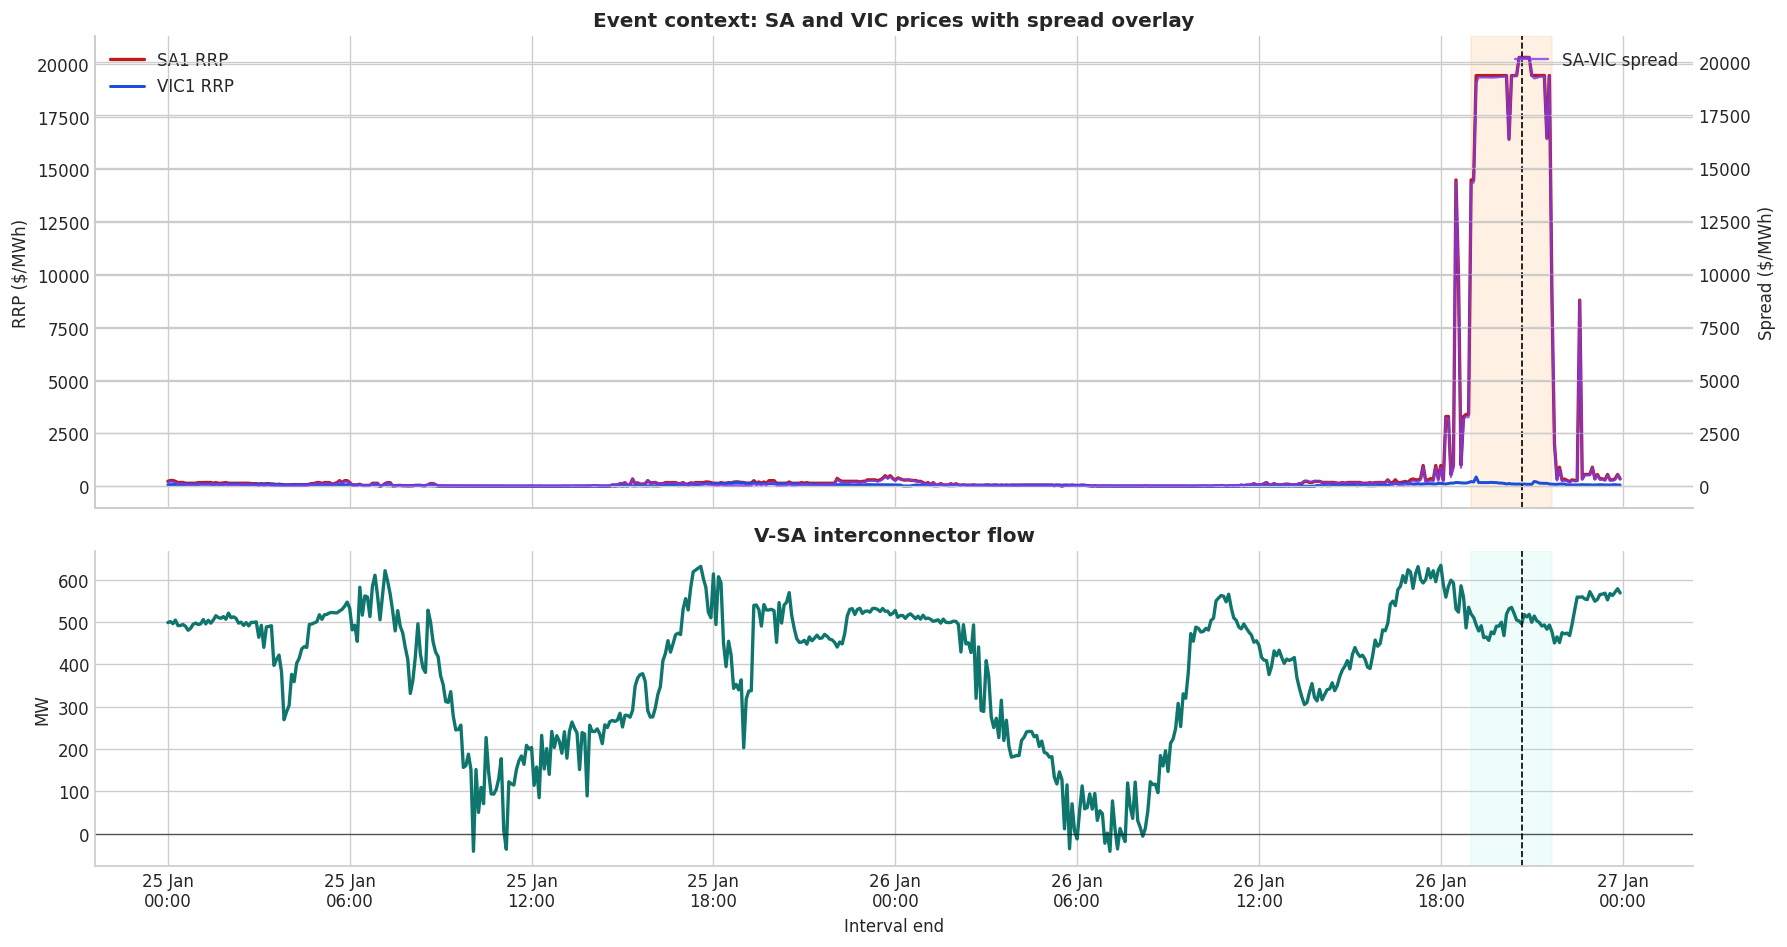

In [6]:
ctx_pd = market_context.to_pandas()
peak_ts = pd.Timestamp(peak_interval)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 8),
    sharex=True,
    height_ratios=[1.5, 1.0],
)

axes[0].plot(ctx_pd["interval_end"], ctx_pd["rrp_sa"], color="#b91c1c", linewidth=2.0, label="SA1 RRP")
axes[0].plot(ctx_pd["interval_end"], ctx_pd["rrp_vic"], color="#1d4ed8", linewidth=1.8, label="VIC1 RRP")
ax_spread = axes[0].twinx()
ax_spread.plot(
    ctx_pd["interval_end"],
    ctx_pd["price_spread"],
    color="#7c3aed",
    linewidth=1.4,
    alpha=0.8,
    label="SA-VIC spread",
)

axes[0].axvline(peak_ts, color="black", linestyle="--", linewidth=1)
axes[0].axvspan(pd.Timestamp(spike_run_start), pd.Timestamp(spike_run_end), color="#fdba74", alpha=0.2)
axes[0].set_ylabel("RRP ($/MWh)")
ax_spread.set_ylabel("Spread ($/MWh)")
axes[0].set_title("Event context: SA and VIC prices with spread overlay")
axes[0].legend(loc="upper left")
ax_spread.legend(loc="upper right")

axes[1].plot(ctx_pd["interval_end"], ctx_pd["v_sa_mw_flow"], color="#0f766e", linewidth=2.0)
axes[1].axhline(0, color="black", linewidth=0.8, alpha=0.6)
axes[1].axvline(peak_ts, color="black", linestyle="--", linewidth=1)
axes[1].axvspan(pd.Timestamp(spike_run_start), pd.Timestamp(spike_run_end), color="#99f6e4", alpha=0.15)
axes[1].set_title("V-SA interconnector flow")
axes[1].set_ylabel("MW")
axes[1].set_xlabel("Interval end")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))

fig.tight_layout()
plt.show()

## Section 2: Constraint Activity Scan

Build the interval-level event frame and rank constraints by how often they were active and how much marginal value they carried through the event.

In [7]:
constraint_event = (
    with_interval_end(
        scan_selected(
            "DISPATCHCONSTRAINT",
            [
                "SETTLEMENTDATE",
                "INTERVENTION",
                "CONSTRAINTID",
                "MARGINALVALUE",
                "VIOLATIONDEGREE",
                "RHS",
                "LHS",
                "GENCONID_EFFECTIVEDATE",
                "GENCONID_VERSIONNO",
            ],
            start=EVENT_START, end=EVENT_END,
        )
    )
    .filter(
        in_event_window(pl.col("interval_end"))
        & (pl.col("INTERVENTION") == 0)
    )
    .select(
        [
            "interval_end",
            pl.col("CONSTRAINTID").alias("constraint_id"),
            pl.col("MARGINALVALUE").alias("marginal_value"),
            pl.col("VIOLATIONDEGREE").alias("violation_degree"),
            pl.col("RHS").alias("rhs"),
            pl.col("LHS").alias("lhs"),
            pl.col("GENCONID_EFFECTIVEDATE").alias("gencon_effective_date"),
            pl.col("GENCONID_VERSIONNO").alias("gencon_version_no"),
        ]
    )
    .collect()
    .with_columns(
        [
            constraint_family_expr(),
            pl.col("marginal_value").abs().alias("abs_marginal_value"),
            (pl.col("marginal_value") != 0).alias("binding_candidate"),
        ]
    )
)

event_frame = (
    constraint_event.join(market_context, on="interval_end", how="left")
    .with_columns(
        [
            pl.lit(VIC_REGION).alias("region_a"),
            pl.lit(SA_REGION).alias("region_b"),
            pl.col("rrp_vic").alias("rrp_a"),
            pl.col("rrp_sa").alias("rrp_b"),
            pl.concat_str(
                [
                    pl.col("constraint_id"),
                    pl.lit("|"),
                    pl.col("gencon_effective_date").cast(pl.String),
                    pl.lit("|v"),
                    pl.col("gencon_version_no").cast(pl.String),
                ]
            ).alias("constraint_fingerprint"),
        ]
    )
)

key_total = event_frame.select(pl.len()).item()
key_unique = event_frame.select(pl.struct(["interval_end", "constraint_id"]).n_unique()).item()
if key_total != key_unique:
    raise ValueError(f"Expected unique interval_end + constraint_id rows, found {key_total - key_unique} duplicates")

analysis_frame = event_frame.filter(
    pl.col("interval_end").is_between(spike_run_start, spike_run_end, closed="both")
)
binding_frame = analysis_frame.filter(pl.col("binding_candidate"))

constraint_summary = (
    binding_frame.group_by(
        ["constraint_id", "constraint_family", "gencon_effective_date", "gencon_version_no"]
    )
    .agg(
        [
            pl.len().alias("active_intervals"),
            pl.max("abs_marginal_value").alias("peak_abs_marginal_value"),
            pl.sum("abs_marginal_value").alias("cumulative_abs_marginal_value"),
        ]
    )
    .sort("cumulative_abs_marginal_value", descending=True)
)

display(constraint_summary.head(10))

run_summary = pl.DataFrame(
    [
        {"metric": "Spike run start", "value": str(spike_run_start)},
        {"metric": "Spike run end", "value": str(spike_run_end)},
        {"metric": "Spike run intervals", "value": str(longest_run["intervals"])},
        {"metric": "Active constraints in spike run", "value": str(binding_frame.select(pl.col("constraint_id").n_unique()).item())},
    ]
)
display(run_summary)

constraint_id,constraint_family,gencon_effective_date,gencon_version_no,active_intervals,peak_abs_marginal_value,cumulative_abs_marginal_value
str,str,str,f64,u32,f64,f64
"""SVML_ZERO""","""SVML_ZERO""","""2013/08/21 00:00:00""",1.0,32,2.3548e7,7.53536e8
"""#GPWFWST2_E1""","""#GPWFWST2_E1""","""2026/01/20 00:00:00""",1.0,33,7.308e6,2.41164e8
"""#GPWFWST1_E1""","""#GPWFWST1_E1""","""2026/01/20 00:00:00""",1.0,33,7.308e6,2.41164e8
"""V_BULGANAWF_FLT_0""","""V_BULGANAWF_FLT_0""","""2025/12/04 00:00:00""",1.0,33,710500.0,2.34465e7
"""T_BLINK_TV_NGZ""","""T_BLINK_TV_NGZ""","""2022/02/07 00:00:00""",1.0,1,7.308e6,7.308e6
"""V^^SML_NSWRB_2""","""V^^SML_NSWRB_2""","""2024/10/31 00:00:00""",1.0,17,710500.0,917929.59704
"""VS_600_TEST""","""VS_600_TEST""","""2025/12/02 00:00:00""",1.0,33,19538.90738,594637.67934
"""#LGAPBS1_E1""","""#LGAPBS1_E1""","""2025/10/29 00:00:00""",1.0,5,20299.98,98931.59
"""$BLOWERNG""","""$BLOWERNG""",null,null,6,1108.73924,6409.83303


metric,value
str,str
"""Spike run start""","""2026-01-26 19:00:00"""
"""Spike run end""","""2026-01-26 21:40:00"""
"""Spike run intervals""","""33"""
"""Active constraints in spike ru…","""62"""


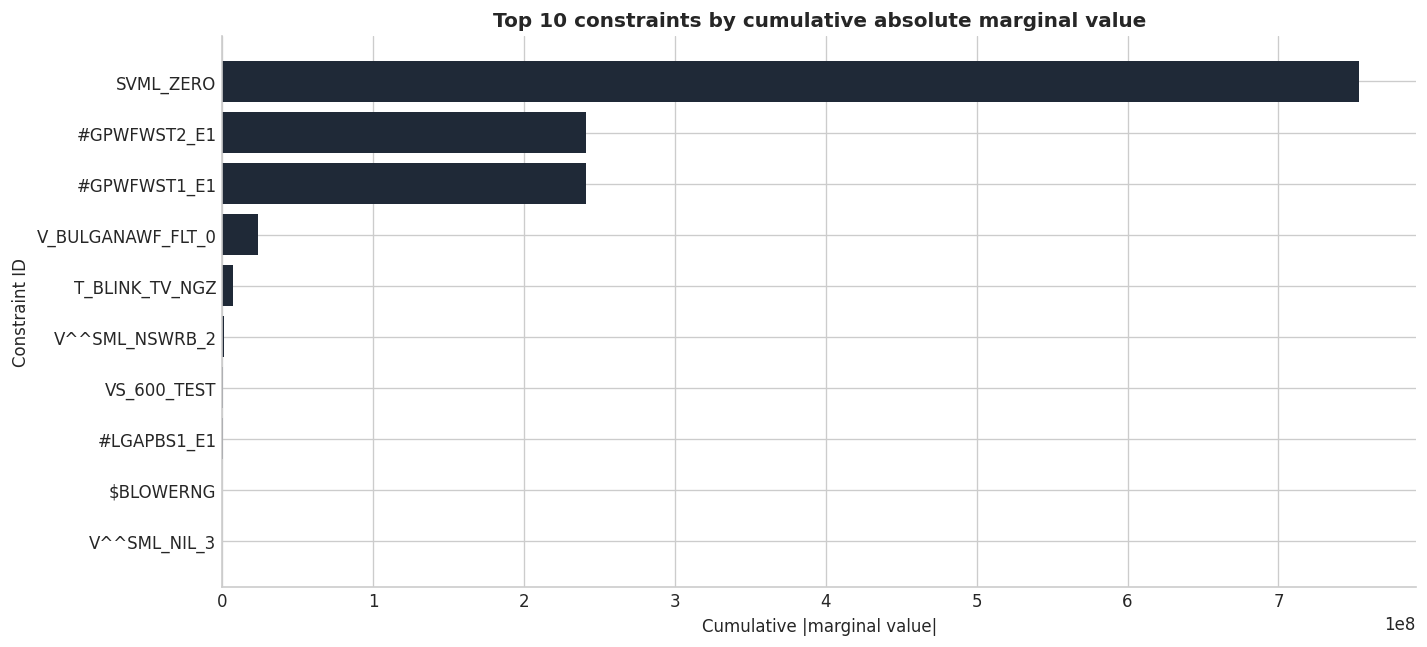

In [8]:
top10 = constraint_summary.head(10).to_pandas()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.barh(
    top10["constraint_id"][::-1],
    top10["cumulative_abs_marginal_value"][::-1],
    color="#1f2937",
)
ax.set_title("Top 10 constraints by cumulative absolute marginal value")
ax.set_xlabel("Cumulative |marginal value|")
ax.set_ylabel("Constraint ID")
fig.tight_layout()
plt.show()

## Section 3: Binding Timeline

Track the dominant constraints through time and compare their marginal values against the realized SA-VIC spread.

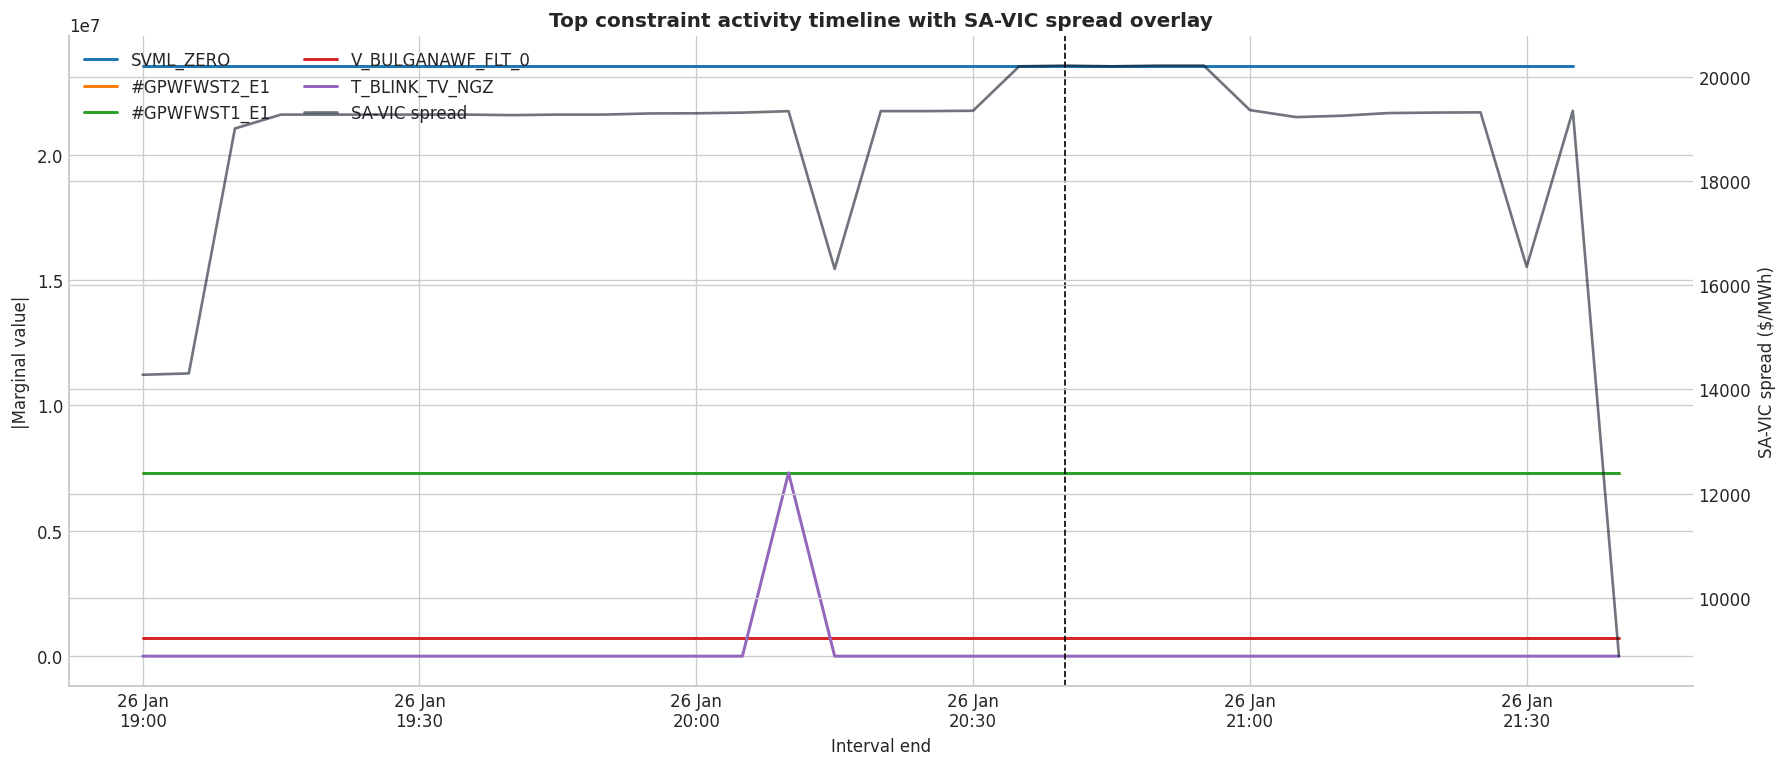

interval_end,constraint_id,marginal_value,violation_degree,gencon_effective_date,gencon_version_no
datetime[μs],str,f64,f64,str,f64
2026-01-26 20:40:00,"""SVML_ZERO""",-2.3548e7,0.0,"""2013/08/21 00:00:00""",1.0
2026-01-26 20:40:00,"""#GPWFWST1_E1""",-7.308e6,0.0,"""2026/01/20 00:00:00""",1.0
2026-01-26 20:40:00,"""#GPWFWST2_E1""",-7.308e6,0.0,"""2026/01/20 00:00:00""",1.0
2026-01-26 20:40:00,"""V_BULGANAWF_FLT_0""",-710500.0,0.0,"""2025/12/04 00:00:00""",1.0
2026-01-26 20:40:00,"""VS_600_TEST""",-19538.90738,0.0,"""2025/12/02 00:00:00""",1.0
…,…,…,…,…,…
2026-01-26 20:40:00,"""F_MAIN+NIL_MG_R5""",0.09,0.0,"""2013/08/21 00:00:00""",1.0
2026-01-26 20:40:00,"""F_MAIN+NIL_MG_R1""",0.04,0.0,"""2025/02/17 00:00:00""",1.0
2026-01-26 20:40:00,"""F_MAIN+BIP_ML_L6""",0.03,0.0,"""2024/07/11 00:00:00""",1.0


In [9]:
top_ids = constraint_summary.head(TOP_N_CONSTRAINTS)["constraint_id"].to_list()

timeline_pd = (
    analysis_frame.filter(pl.col("constraint_id").is_in(top_ids))
    .select(["interval_end", "constraint_id", "abs_marginal_value"])
    .to_pandas()
)
spread_pd = spike_market_context.select(["interval_end", "price_spread"]).to_pandas()

fig, ax = plt.subplots(figsize=(15, 6.5))
for constraint_id in top_ids:
    series = timeline_pd[timeline_pd["constraint_id"] == constraint_id].sort_values("interval_end")
    ax.plot(series["interval_end"], series["abs_marginal_value"], linewidth=1.8, label=constraint_id)

ax2 = ax.twinx()
ax2.plot(
    spread_pd["interval_end"],
    spread_pd["price_spread"],
    color="#111827",
    linewidth=1.6,
    alpha=0.6,
    label="SA-VIC spread",
)

ax.axvline(pd.Timestamp(peak_interval), color="black", linestyle="--", linewidth=1)
ax.set_title("Top constraint activity timeline with SA-VIC spread overlay")
ax.set_ylabel("|Marginal value|")
ax2.set_ylabel("SA-VIC spread ($/MWh)")
ax.set_xlabel("Interval end")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", ncol=2)

fig.tight_layout()
plt.show()

active_at_peak = (
    binding_frame.filter(pl.col("interval_end") == peak_interval)
    .sort("abs_marginal_value", descending=True)
    .select(
        [
            "interval_end",
            "constraint_id",
            "marginal_value",
            "violation_degree",
            "gencon_effective_date",
            "gencon_version_no",
        ]
    )
)

display(active_at_peak)

## Section 4: Constraint Identity For This Case Study

Use the event-period identity fields to build a reproducible constraint catalog for the dominant fingerprints in this solve window.

In [10]:
identity_catalog = (
    constraint_summary.select(
        [
            "constraint_id",
            "constraint_family",
            "gencon_effective_date",
            "gencon_version_no",
            "active_intervals",
            "peak_abs_marginal_value",
            "cumulative_abs_marginal_value",
        ]
    )
    .head(15)
)

display(identity_catalog)

dominant_row = constraint_summary.row(0, named=True)
dominant_id = dominant_row["constraint_id"]
dominant_fingerprint = (
    f"{dominant_row['constraint_id']} | {dominant_row['gencon_effective_date']} | v{dominant_row['gencon_version_no']}"
)

rotating_fingerprints = constraint_summary.filter(
    pl.col("cumulative_abs_marginal_value")
    >= dominant_row["cumulative_abs_marginal_value"] * 0.25
).height

identity_note = f'''
### Identity Read

The dominant fingerprint in this case window was **{dominant_fingerprint}**.

There were **{rotating_fingerprints}** fingerprints with at least 25% of the dominant cumulative absolute marginal value. That gives a quick read on whether one equation-version pair dominated the event or whether control rotated across several constraints.
'''

display(Markdown(identity_note))

constraint_id,constraint_family,gencon_effective_date,gencon_version_no,active_intervals,peak_abs_marginal_value,cumulative_abs_marginal_value
str,str,str,f64,u32,f64,f64
"""SVML_ZERO""","""SVML_ZERO""","""2013/08/21 00:00:00""",1.0,32,2.3548e7,7.53536e8
"""#GPWFWST2_E1""","""#GPWFWST2_E1""","""2026/01/20 00:00:00""",1.0,33,7.308e6,2.41164e8
"""#GPWFWST1_E1""","""#GPWFWST1_E1""","""2026/01/20 00:00:00""",1.0,33,7.308e6,2.41164e8
"""V_BULGANAWF_FLT_0""","""V_BULGANAWF_FLT_0""","""2025/12/04 00:00:00""",1.0,33,710500.0,2.34465e7
"""T_BLINK_TV_NGZ""","""T_BLINK_TV_NGZ""","""2022/02/07 00:00:00""",1.0,1,7.308e6,7.308e6
…,…,…,…,…,…,…
"""N^^V_BADP_1""","""N^^V_BADP_1""","""2025/12/18 00:00:00""",1.0,33,319.80721,2685.47936
"""$CPP_3""","""$CPP_3""",null,null,14,240.73,2684.565
"""N>>NIL_33_34""","""N>>NIL_33_34""","""2025/12/02 00:00:00""",1.0,28,189.39672,2192.30041



### Identity Read

The dominant fingerprint in this case window was **SVML_ZERO | 2013/08/21 00:00:00 | v1.0**.

There were **3** fingerprints with at least 25% of the dominant cumulative absolute marginal value. That gives a quick read on whether one equation-version pair dominated the event or whether control rotated across several constraints.


## Section 5: Constraint-To-Market Linkage

Compare the dominant constraint directly against realized spread intensity and summarize the top price intervals with their active constraints.

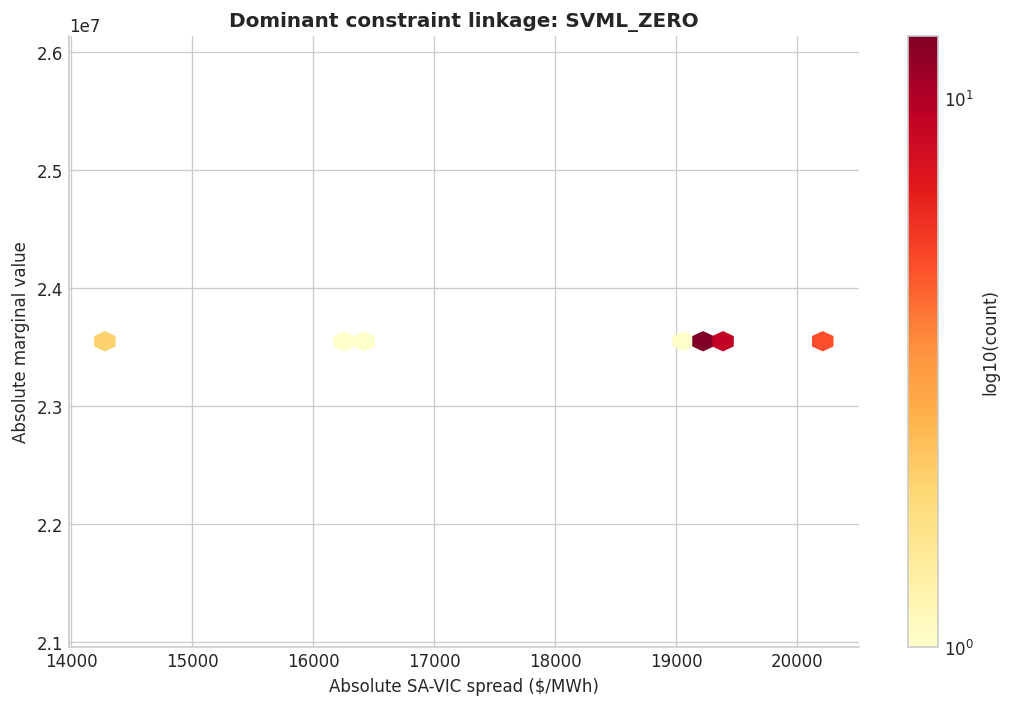

interval_end,rrp_sa,rrp_vic,price_spread,v_sa_mw_flow,top_constraint_ids,top_marginal_values
datetime[μs],f64,f64,f64,f64,str,str
2026-01-26 20:35:00,20299.98,104.03,20195.95,502.71611,"""SVML_ZERO, #GPWFWST1_E1, #GPWF…","""-23548000.0, -7308000.0, -7308…"
2026-01-26 20:40:00,20300.0,88.99,20211.01,496.03793,"""SVML_ZERO, #GPWFWST2_E1, #GPWF…","""-23548000.0, -7308000.0, -7308…"
2026-01-26 20:45:00,20300.0,104.03,20195.97,518.16043,"""SVML_ZERO, #GPWFWST2_E1, #GPWF…","""-23548000.0, -7308000.0, -7308…"
2026-01-26 20:50:00,20300.0,88.99,20211.01,512.472,"""SVML_ZERO, #GPWFWST2_E1, #GPWF…","""-23548000.0, -7308000.0, -7308…"
2026-01-26 20:55:00,20299.98,88.99,20210.99,518.45414,"""SVML_ZERO, #GPWFWST2_E1, #GPWF…","""-23548000.0, -7308000.0, -7308…"
…,…,…,…,…,…,…
2026-01-26 21:10:00,19445.52,197.63531,19247.88469,503.33029,"""SVML_ZERO, #GPWFWST2_E1, #GPWF…","""-23548000.0, -7308000.0, -7308…"
2026-01-26 21:15:00,19445.56,146.19001,19299.36999,499.20204,"""SVML_ZERO, #GPWFWST2_E1, #GPWF…","""-23548000.0, -7308000.0, -7308…"
2026-01-26 21:20:00,19445.56,137.08951,19308.47049,490.92473,"""SVML_ZERO, #GPWFWST2_E1, #GPWF…","""-23548000.0, -7308000.0, -7308…"



### Linkage Read

Across the top SA price intervals in this case study, the dominant constraint led the interval ranking about **100.0%** of the time. That is enough to distinguish between one persistent driver and a materially rotating set of active constraints.


In [11]:
dominant_df = (
    analysis_frame.filter(pl.col("constraint_id") == dominant_id)
    .select(["interval_end", "abs_price_spread", "abs_marginal_value"])
    .to_pandas()
    .sort_values("interval_end")
)

fig, ax = plt.subplots(figsize=(9, 6))
hb = ax.hexbin(
    dominant_df["abs_price_spread"],
    dominant_df["abs_marginal_value"],
    gridsize=36,
    cmap="YlOrRd",
    mincnt=1,
    bins="log",
)
ax.set_title(f"Dominant constraint linkage: {dominant_id}")
ax.set_xlabel("Absolute SA-VIC spread ($/MWh)")
ax.set_ylabel("Absolute marginal value")
fig.colorbar(hb, ax=ax, label="log10(count)")
fig.tight_layout()
plt.show()

interval_constraint_top = (
    binding_frame.sort(["interval_end", "abs_marginal_value"], descending=[False, True])
    .group_by("interval_end")
    .agg(
        [
            pl.col("constraint_id").head(3).alias("top_constraint_ids"),
            pl.col("marginal_value").head(3).alias("top_marginal_values"),
        ]
    )
    .with_columns(
        [
            pl.col("top_constraint_ids").list.join(", ").alias("top_constraint_ids"),
            pl.col("top_marginal_values")
            .list.eval(pl.element().round(2).cast(pl.String))
            .list.join(", ")
            .alias("top_marginal_values"),
        ]
    )
)

top_spike_intervals = (
    spike_market_context.sort("rrp_sa", descending=True)
    .head(12)
    .select(["interval_end", "rrp_sa", "rrp_vic", "price_spread", "v_sa_mw_flow"])
    .join(interval_constraint_top, on="interval_end", how="left")
    .sort("interval_end")
)

display(top_spike_intervals)

same_constraint_share = (
    top_spike_intervals
    .with_columns(
        pl.col("top_constraint_ids")
        .fill_null("")
        .str.starts_with(dominant_id)
        .alias("dominant_leads_interval")
    )
    .select(pl.mean("dominant_leads_interval"))
    .item()
)

linkage_note = f'''
### Linkage Read

Across the top SA price intervals in this case study, the dominant constraint led the interval ranking about **{same_constraint_share * 100:.1f}%** of the time. That is enough to distinguish between one persistent driver and a materially rotating set of active constraints.
'''

display(Markdown(linkage_note))

## Section 6: Findings

End the notebook with a compact set of analyst takeaways that separate realized congestion symptoms from interval-level binding attribution.

In [12]:
peak_active_count = active_at_peak.height
max_spread = spike_market_context.select(pl.max("abs_price_spread")).item()
min_flow = spike_market_context.select(pl.min("v_sa_mw_flow")).item()
max_flow = spike_market_context.select(pl.max("v_sa_mw_flow")).item()
dominant_share = (
    binding_frame.with_columns((pl.col("constraint_id") == dominant_id).alias("is_dominant"))
    .select(pl.mean("is_dominant"))
    .item()
)

findings_md = f'''
### Analyst Takeaways

- The Jan 26, 2026 SA event can be extended from realized price and flow symptoms into interval-level binding attribution using `DISPATCHCONSTRAINT` alone.
- The dominant constraint by cumulative absolute marginal value was **{dominant_id}**.
- At the SA peak price interval (**{peak_interval}**), there were **{peak_active_count}** non-zero-marginal constraints active.
- SA-VIC separation reached about **${max_spread:,.0f}/MWh** while `V-SA` flow ranged from **{min_flow:,.0f} MW** to **{max_flow:,.0f} MW** over the same event window.
- Realized interconnector tightness and named binding constraints are complementary evidence types: flow and spread show what the market experienced, while `DISPATCHCONSTRAINT` shows which equations carried non-zero marginal value in the solve.
- The dominant constraint accounted for about **{dominant_share * 100:.1f}%** of active constraint-interval observations, which helps distinguish between one persistent driver and a more rotational binding set.
- This notebook supports interval-level attribution for the case study, but it does not reconstruct the full NEMDE solve or recover missing transfer-limit fields from the local parquet cache.
'''

display(Markdown(findings_md))


### Analyst Takeaways

- The Jan 26, 2026 SA event can be extended from realized price and flow symptoms into interval-level binding attribution using `DISPATCHCONSTRAINT` alone.
- The dominant constraint by cumulative absolute marginal value was **SVML_ZERO**.
- At the SA peak price interval (**2026-01-26 20:40:00**), there were **28** non-zero-marginal constraints active.
- SA-VIC separation reached about **$20,211/MWh** while `V-SA` flow ranged from **457 MW** to **535 MW** over the same event window.
- Realized interconnector tightness and named binding constraints are complementary evidence types: flow and spread show what the market experienced, while `DISPATCHCONSTRAINT` shows which equations carried non-zero marginal value in the solve.
- The dominant constraint accounted for about **4.0%** of active constraint-interval observations, which helps distinguish between one persistent driver and a more rotational binding set.
- This notebook supports interval-level attribution for the case study, but it does not reconstruct the full NEMDE solve or recover missing transfer-limit fields from the local parquet cache.
